# Data Science With Python
**Data Science Course — Video Submission Assignment**

Following the Simplilearn tutorial: *Data Science With Python | Python for Data Science*

Topics covered:
- Importing required Python libraries
- Loading and exploring the loan prediction dataset
- Univariate visualizations (histograms)
- Data wrangling: detecting and filling missing values
- Building a logistic regression model with scikit-learn

## Step 1 — Import Required Libraries
We import the three core data science libraries:
- **pandas** — for loading and manipulating the dataset
- **numpy** — for numerical operations and array support
- **matplotlib** — for data visualizations

The magic command `%matplotlib inline` ensures all charts are displayed directly inside the notebook.

In [1]:
import pandas as pd        # data manipulation and DataFrame operations
import numpy as np         # numerical computing and array support
import matplotlib.pyplot as plt  # data visualization

# render all matplotlib charts inline inside the notebook
%matplotlib inline

Matplotlib is building the font cache; this may take a moment.


## Step 2 — Load the Dataset
We use `pd.read_csv()` to read the loan prediction CSV file into a pandas DataFrame.
A DataFrame is a two-dimensional table with labelled rows and columns — similar to a spreadsheet or SQL table.

In [2]:
# read the CSV file into a DataFrame named 'df'
# pd.read_csv() automatically detects columns and data types
df = pd.read_csv('loanP_train.csv')

## Step 3 — Preview the Data
`df.head()` returns the first 5 rows of the DataFrame so we can quickly see the column names and sample values.

In [3]:
# display the first 5 rows — gives a quick overview of the data structure
df.head()

,Loan_ID,Gender,Marital_Status,Dependents,Graduate,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LI0100,Male,Single,0,Yes,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LI0101,Male,Married,1,Yes,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LI0102,Male,Married,0,Yes,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LI0103,Male,Married,0,No,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LI0104,Male,Single,0,Yes,No,6000,0.0,141.0,360.0,1.0,Urban,Y


## Step 4 — Statistical Summary
`df.describe()` gives a statistical summary of all **numerical** columns:
count, mean, standard deviation, min, max, and quartile values.
This helps us understand the spread and scale of the data.

In [4]:
# statistical summary: count, mean, std, min, 25%, 50%, 75%, max
# only numerical columns are included automatically
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,599.000000,599.000000,578.000000,585.000000,550.00000
mean,5420.687813,1563.913055,145.434256,342.461538,0.84000
std,6169.168633,2456.618360,84.596463,64.868352,0.36694
min,150.000000,0.000000,9.000000,12.000000,0.00000
25%,2874.000000,0.000000,100.000000,360.000000,1.00000
50%,3812.000000,1210.000000,126.500000,360.000000,1.00000
75%,5807.500000,2279.000000,165.000000,360.000000,1.00000
max,81000.000000,33837.000000,700.000000,480.000000,1.00000


## Step 5 — Univariate Data Visualization (Histograms)
We plot histograms for key numerical columns to understand how the data is distributed.
Histograms reveal whether a column has extreme/outlier values that may need to be handled before modeling.

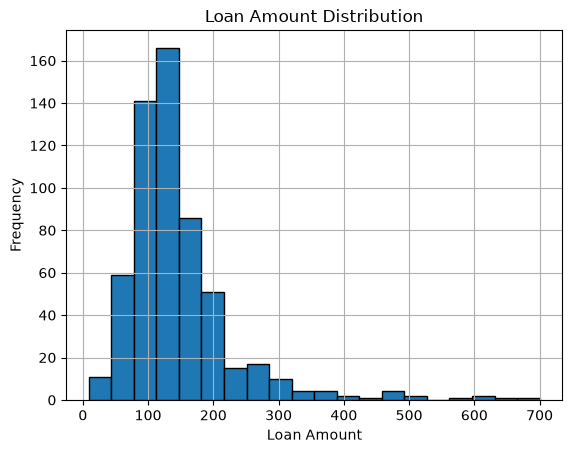

In [5]:
# histogram of LoanAmount — shows distribution of loan amounts requested
# most values cluster between 0-300 but there are extreme values near 700
df['LoanAmount'].hist(bins=20, edgecolor='black')
plt.title('Loan Amount Distribution')
plt.xlabel('Loan Amount')
plt.ylabel('Frequency')
plt.show()

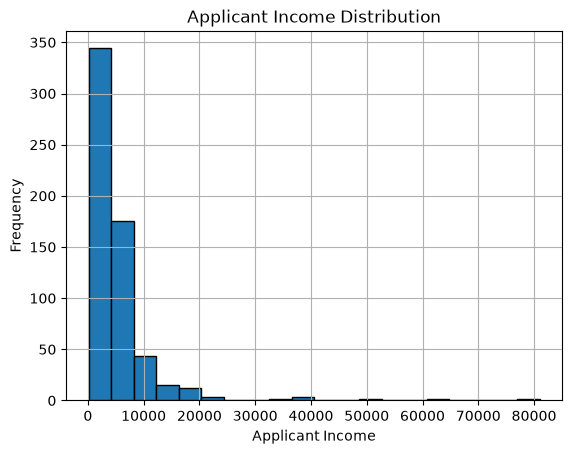

In [6]:
# histogram of ApplicantIncome — shows how applicant incomes are distributed
# most applicants earn under 20,000 but a few outliers reach 80,000+
df['ApplicantIncome'].hist(bins=20, edgecolor='black')
plt.title('Applicant Income Distribution')
plt.xlabel('Applicant Income')
plt.ylabel('Frequency')
plt.show()

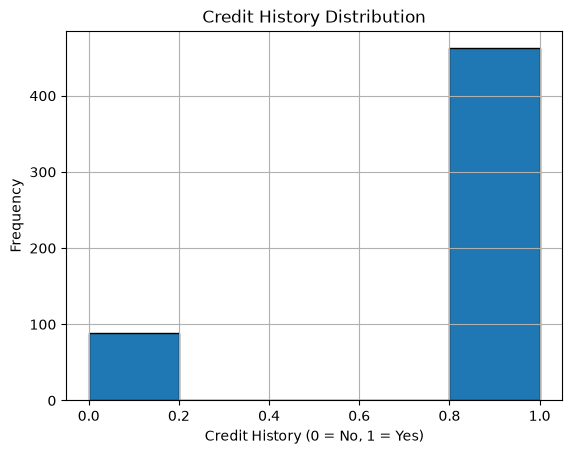

In [7]:
# histogram of Credit_History — a binary flag: 1 = has credit history, 0 = does not
# the chart shows the majority of applicants have a credit history (value = 1)
df['Credit_History'].hist(bins=5, edgecolor='black')
plt.title('Credit History Distribution')
plt.xlabel('Credit History (0 = No, 1 = Yes)')
plt.ylabel('Frequency')
plt.show()

## Step 6 — Detect Missing Values (Data Wrangling)
Real-world data is rarely clean. We use a lambda function with `df.apply()` to count
the number of missing (null) entries in each column.

This is the first step of **data wrangling** — identifying dirty data before cleaning it.

In [8]:
# apply a lambda function across every column to count null (missing) values
# x.isnull() returns True/False for each cell; sum() counts the True values
df.apply(lambda x: sum(x.isnull()))

Loan_ID               0
Gender               13
Marital_Status        3
Dependents           15
Graduate              0
Self_Employed        30
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           21
Loan_Amount_Term     14
Credit_History       49
Property_Area         0
Loan_Status           0
dtype: int64

## Step 7 — Fill Missing Values
For numerical columns with missing values we replace each missing cell with the **column mean**.
Using the mean keeps the filled value within the realistic range of the existing data,
without pulling the distribution too high or too low.

In [9]:
# fill the 21 missing LoanAmount values with the column's mean
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].mean())

# fill the 14 missing Loan_Amount_Term values with the column's mean
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mean())

# fill the 49 missing Credit_History values with the column's mean
df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].mean())

## Step 8 — Verify Missing Values Are Resolved
After filling, we re-run the same missing value check to confirm that LoanAmount,
Loan_Amount_Term, and Credit_History now show 0 missing entries.

In [10]:
# re-check missing values — LoanAmount, Loan_Amount_Term, Credit_History should now be 0
df.apply(lambda x: sum(x.isnull()))

Loan_ID               0
Gender               13
Marital_Status        3
Dependents           15
Graduate              0
Self_Employed        30
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            0
Loan_Amount_Term      0
Credit_History        0
Property_Area         0
Loan_Status           0
dtype: int64

## Step 9 — Mean of All Numerical Columns
`df.mean()` calculates and displays the average value for every numerical column in the DataFrame.
This gives a quick summary of the central tendency across the dataset.

In [11]:
# calculate the mean for all numerical columns in the DataFrame
df.mean(numeric_only=True)

ApplicantIncome      5420.687813
CoapplicantIncome    1563.913055
LoanAmount            145.434256
Loan_Amount_Term      342.461538
Credit_History          0.840000
dtype: float64

## Step 10 — Inspect Data Types
`df.dtypes` shows the data type of each column (e.g. int64, float64, object/str).
This is important before machine learning because algorithms require numerical input —
categorical text columns must be encoded first.

In [12]:
# display the data type of every column
# str/object columns will need to be encoded to numbers before modeling
df.dtypes

Loan_ID                  str
Gender                   str
Marital_Status           str
Dependents               str
Graduate                 str
Self_Employed            str
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area            str
Loan_Status              str
dtype: object

---
## Step 11 — Machine Learning: Logistic Regression
We now build a predictive model using **scikit-learn**.

**Goal**: predict whether a loan application will be approved (`Loan_Status = Y`) or denied (`N`).
This is a **binary classification** problem — logistic regression is the appropriate algorithm.

Steps:
1. Import scikit-learn modules
2. Encode categorical columns to numbers
3. Separate independent variables (X) from the target variable (y)
4. Split data into training (75%) and test (25%) sets
5. Scale features with StandardScaler
6. Train the logistic regression classifier
7. Predict on the test set
8. Evaluate with confusion matrix and accuracy score

In [13]:
# import the scikit-learn modules needed for this machine learning workflow
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score

In [14]:
# fill remaining missing values in categorical columns using each column's mode (most frequent value)
# this ensures no NaN values remain before encoding
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])
df['Marital_Status'] = df['Marital_Status'].fillna(df['Marital_Status'].mode()[0])
df['Dependents'] = df['Dependents'].fillna(df['Dependents'].mode()[0])
df['Self_Employed'] = df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])

# LabelEncoder converts text categories to integers (e.g. Male=1, Female=0)
# machine learning algorithms require numeric input, not text strings
le = LabelEncoder()
for col in ['Gender', 'Marital_Status', 'Dependents', 'Graduate',
            'Self_Employed', 'Property_Area', 'Loan_Status']:
    df[col] = le.fit_transform(df[col])

# drop Loan_ID — it is just an identifier and adds no predictive value
df = df.drop(columns=['Loan_ID'])

df.head()

,Gender,Marital_Status,Dependents,Graduate,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,1,0,1,0,5849,0.0,145.434256,360.0,1.0,2,1
1,1,0,1,1,0,4583,1508.0,128.000000,360.0,1.0,0,0
2,1,0,0,1,1,3000,0.0,66.000000,360.0,1.0,2,1
3,1,0,0,0,0,2583,2358.0,120.000000,360.0,1.0,2,1
4,1,1,0,1,0,6000,0.0,141.000000,360.0,1.0,2,1


In [15]:
# X = independent variables (all columns except the target)
# y = dependent variable (the target we want to predict: Loan_Status)
X = df.drop(columns=['Loan_Status'])
y = df['Loan_Status']

print('Independent variables (X) shape:', X.shape)
print('Target variable (y) shape:', y.shape)

Independent variables (X) shape: (599, 11)
Target variable (y) shape: (599,)


In [16]:
# split the dataset into training data (75%) and test data (25%)
# random_state=0 ensures the same split every time (reproducibility)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0
)

print('Training set size:', X_train.shape[0])
print('Test set size:    ', X_test.shape[0])

Training set size: 449
Test set size:     150


In [17]:
# StandardScaler normalizes features so they all have mean=0, std=1
# this prevents columns with large values (like ApplicantIncome) from dominating the model
sc = StandardScaler()
X_train = sc.fit_transform(X_train)  # fit on training data and transform it
X_test = sc.transform(X_test)        # transform test data using the same fitted scaler

In [18]:
# create an instance of the LogisticRegression classifier
classifier = LogisticRegression(random_state=0)

# train (fit) the model on the training data
# .fit() learns the relationship between X_train (features) and y_train (labels)
classifier.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",0
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver

In [19]:
# predict loan approval outcomes for the test set
# we only pass X_test (independent variables); y values are predicted by the model
y_pred = classifier.predict(X_test)

# display the predicted values: 1 = approved (Y), 0 = denied (N)
print('Predicted loan outcomes (1=Approved, 0=Denied):')
print(y_pred)

Predicted loan outcomes (1=Approved, 0=Denied):
[1 0 1 0 1 1 1 1 1 0 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 0 1 1 1 1 1 1 1 0 1 1 0 0 1 0 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1
 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 0 1 1 0 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 1 0 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1]


In [20]:
# confusion matrix compares the model's predictions against the actual known labels
# rows = actual values, columns = predicted values
# diagonal values (top-left, bottom-right) = correct predictions
# off-diagonal values = incorrect predictions
cm = confusion_matrix(y_test, y_pred)
print('Confusion Matrix:')
print(cm)

Confusion Matrix:
[[ 18  27]
 [  2 103]]


In [21]:
# accuracy score = (correct predictions) / (total predictions)
# calculated automatically from y_test (actual) vs y_pred (predicted)
acc = accuracy_score(y_test, y_pred)
print(f'Model Accuracy: {acc:.4f} ({acc*100:.2f}%)')

Model Accuracy: 0.8067 (80.67%)
